In [1]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# FantasyToolz stat-scraping library
import mlbstatscraping as mss

# probability helpers
from scipy.stats import beta, binom
from scipy.odr import ODR, Model, RealData



In [2]:
P2026 = pd.read_csv("../data/Preseason/Aggregate/Summaries/2026mean-player-batting-order.csv")
P2025 = pd.read_csv("../data/Preseason/Aggregate/Summaries/2025mean-player-batting-order.csv")
S2025 = pd.read_csv("../data/Aggregate/Summaries/2025mean-player-batting-order.csv")

In [3]:
A2525 = pd.merge(P2025, S2025, on="player", how="outer", suffixes=("_preseason", "_season"))
A2526 = pd.merge(P2026, S2025, on="player", how="outer", suffixes=("_preseason", "_season"))

In [4]:
A2525

,player,avg_preseason,ngames_preseason,teamgames_preseason,team_preseason,avg_season,ngames_season,teamgames_season,team_season
0,A.J. Vukovich,7.50,2.0,34.0,AZ,NaN,NaN,NaN,NaN
1,Aaron Judge,2.00,14.0,33.0,NYY,2.49,150.0,162.0,NYY
2,Aaron Schunk,8.57,7.0,33.0,COL,8.80,10.0,162.0,COL
3,Abraham Toro,6.10,10.0,29.0,BOS,5.97,67.0,162.0,BOS
4,Adael Amador,8.38,8.0,33.0,COL,8.67,36.0,162.0,COL
...,...,...,...,...,...,...,...,...,...
922,Zach McKinstry,5.21,14.0,31.0,DET,6.20,128.0,162.0,DET
923,Zach Neto,NaN,NaN,NaN,NaN,1.25,122.0,162.0,LAA
924,Zack Gelof,5.38,13.0,31.0,ATH,8.08,26.0,162.0,ATH
925,Zack Short,7.38,8.0,29.0,HOU,8.40,15.0,162.0,HOU


In [5]:
A2525 = A2525.fillna(0)
A2526 = A2526.fillna(0)

Text(0, 0.5, 'season batting order')

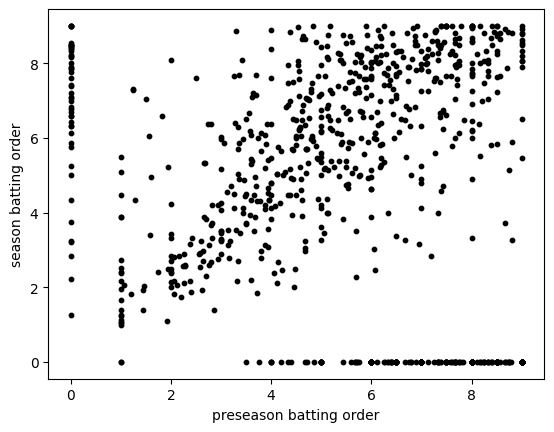

In [6]:
plt.scatter(A2525["avg_preseason"], A2525["avg_season"],color='black',s=10)
plt.xlabel("preseason batting order")
plt.ylabel("season batting order")

Text(0, 0.5, 'season games')

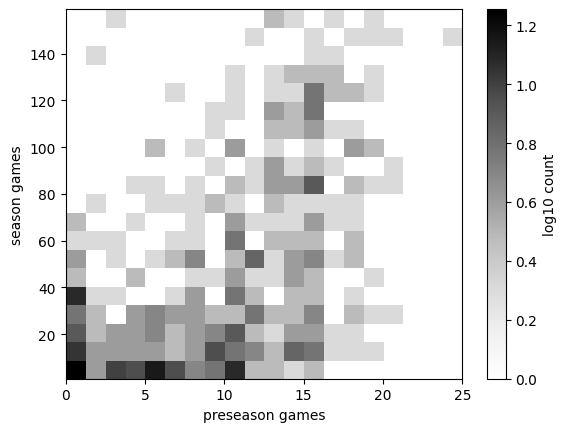

In [7]:
# Create 2D histogram
criteria = (A2525["avg_preseason"] >= 0) & (A2525["avg_season"] > 5)
hist, xedges, yedges = np.histogram2d(A2525["ngames_preseason"][criteria], A2525["ngames_season"][criteria], bins=20)
plt.imshow(np.log10(hist.T + 1), origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto', cmap=cm.Greys)
plt.colorbar(label='log10 count')
plt.xlabel("preseason games")
plt.ylabel("season games")

Text(0, 0.5, 'season games')

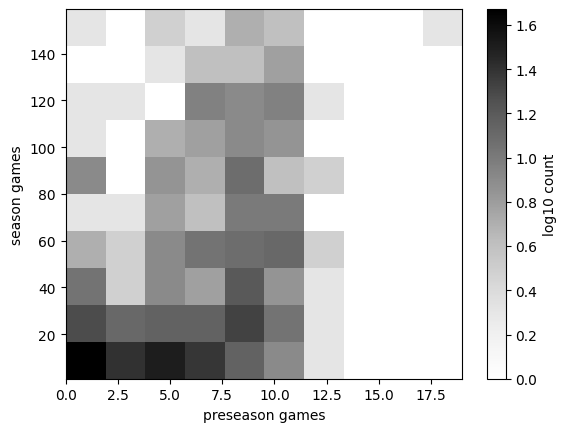

In [9]:
# Create 2D histogram
criteria = (A2526["avg_preseason"] >= 0) & (A2526["avg_season"] > 5)
hist, xedges, yedges = np.histogram2d(A2526["ngames_preseason"][criteria], A2526["ngames_season"][criteria], bins=10)
plt.imshow(np.log10(hist.T + 1), origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto', cmap=cm.Greys)
plt.colorbar(label='log10 count')
plt.xlabel("preseason games")
plt.ylabel("season games")

In [12]:
A2526[criteria][(A2526["ngames_preseason"][criteria] > 8) & (A2526["ngames_season"][criteria] < 30)]

,player,avg_preseason,ngames_preseason,teamgames_preseason,team_preseason,avg_season,ngames_season,teamgames_season,team_season
25,Alex Freeland,4.33,12.0,19.0,LAD,7.76,25.0,162.0,LAD
76,Billy Cook,7.00,10.0,19.0,PIT,9.00,1.0,162.0,PIT
126,Bryan De La Cruz,5.78,9.0,18.0,PHI,6.25,12.0,162.0,ATL
133,Bryce Johnson,3.00,9.0,19.0,SD,7.94,16.0,162.0,SD
176,Cesar Salazar,8.89,9.0,19.0,HOU,9.00,3.0,162.0,HOU
177,Chad Stevens,7.78,9.0,19.0,COL,9.00,5.0,162.0,LAA
183,Chas McCormick,5.36,11.0,19.0,CHC,8.32,28.0,162.0,HOU
188,Chris Taylor,6.00,10.0,20.0,LAA,6.75,28.0,162.0,LAA
216,Connor Joe,5.44,9.0,20.0,SEA,7.94,18.0,162.0,SD
313,Esteury Ruiz,4.20,10.0,17.0,MIA,8.50,6.0,162.0,LAD
